# Fashion Deep Learning Recommendation Systems

*Download the Dataset from here <a href=https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small>Dataset</a>
All the code is given. You need to download the data and train the model using the following code and save the model. Then, create a streamlit app to recommend similar products.

<img src='dataset-cover.png'>

In [44]:
import numpy as np
import pickle as pkl
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPool2D
from PIL import Image as PIL_Image

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm

In [5]:
#Extract Filenames from Folder

In [6]:
filenames = []
for file in os.listdir('images'):
    filenames.append(os.path.join('images',file))
    

In [7]:
len(filenames)

44441

In [8]:
#Importing ResNet50 Model and Cofiguration

In [12]:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model.trainable = False

model = tf.keras.models.Sequential([model,
                                   GlobalMaxPool2D()
                                   ])
model.summary()

E0000 00:00:1786793191.545011 2138761 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
model.save('model_resnet50.h5')

In [20]:
model.save('model_resnet50.keras')

In [10]:
#Extracting Fetaures from Image

In [9]:
def extract_features_from_images(image_path, model):
    img = image.load_img(image_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array, axis=0)
    img_preprocess = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocess).flatten()
    norm_result = result/norm(result)
    return norm_result

In [13]:
#Loading Pickle Files

In [3]:
Image_features = pkl.load(open('Images_features.pkl','rb'))

In [27]:
print(Image_features[0])

[0.01021946 0.0193413  0.00887206 ... 0.00553257 0.03850966 0.12365662]


In [4]:
filenames = pkl.load(open('filenames.pkl','rb'))

In [26]:
print(filenames[0])

images/20137.jpg


In [5]:
np.array(Image_features).shape

(44441, 2048)

In [ ]:
# Extract features for all images
image_features = []
for file in filenames:
    image_features.append(extract_features_from_images(file, model))

In [ ]:
# Save features
pkl.dump(image_features, open('Images_features.pkl', 'wb'))
pkl.dump(filenames, open('filenames.pkl', 'wb'))


In [ ]:
#Finidng Simialar Images

In [7]:
# Fit nearest neighbors on the full feature set
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')
neighbors.fit(Image_features)

,n_neighbors,6
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


In [34]:
def recommend_products(filename,model, neighbors):
    input_image = extract_features_from_images(filename, model)
    distance, indices = neighbors.kneighbors([input_image])
    return indices, distance

In [75]:
def display_recommendations(query_img,filenames, model, neighbors):


    indices, distance = recommend_products(query_img, model, neighbors)
    plt.Figure(figsize=(6, 4))
    plt.title("Query Image")
    query_img = PIL_Image.open(query_img)
    plt.imshow(query_img)
    plt.axis('off')


    plt.figure(figsize = (18,4))
    plt.suptitle("Recommended Images", fontsize=16, fontweight="bold", y=1.02)
    for i in range(5):
        idx = int(indices[0][i+1])  # Skip the first index as it is the query image itself
        img_path = filenames[idx]
        
        img = PIL_Image.open(img_path)
        
        plt.subplot(1, 6, i + 1)
        plt.title(f"Distance: {distance[0][i]:.4f}")
        plt.imshow(img)
        plt.axis('off')
    plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


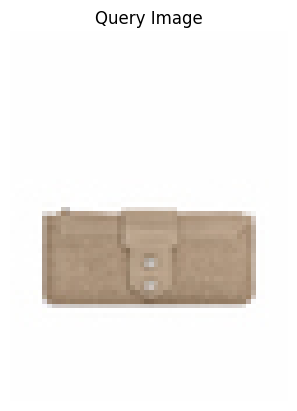

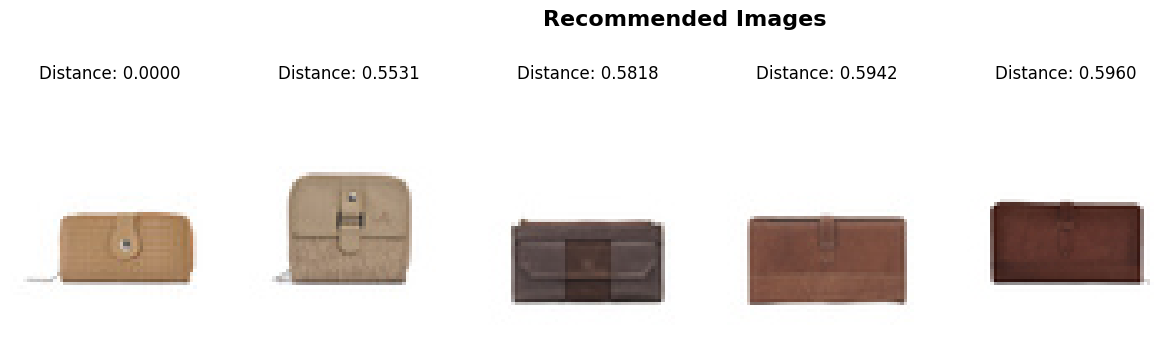

In [76]:
display_recommendations(filenames[1],filenames, model, neighbors)